# RFM Calculation

## Importing Required Libraries And Scripts

In [2]:
import pandas as pd
import datetime as dt
import os
import sys

# --- Path ---
# Adding project root to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

# --- Importing Custom Scripts ---
from scripts import utils

# loading processed_data.csv
try:
    df_clean = pd.read_csv('../data/processed_data.csv', encoding='utf-8')
    # Convert the date column back to datetime format
    df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
    print("Cleaned data loaded successfully.")
except FileNotFoundError:
    print("processed_data.csv not found. Please clean and save the data in the previous notebook.")

Cleaned data loaded successfully.


## Preprocessing for RFM

In [3]:
# Calculating TotalPrice field
df_processed = utils.preprocess_data(df_clean.copy())
display(df_processed.head())

Calculated TotalPrice column.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,537359,22469,HEART OF WICKER SMALL,22,2024-01-26 13:12:00,11.32,12813,Netherlands,249.04
1,538693,71053,WHITE METAL LANTERN,46,2024-12-06 23:36:00,19.71,14324,United Kingdom,906.66
2,537160,22086,PAPER CHAIN KIT 50'S CHRISTMAS,4,2024-04-26 05:36:00,4.64,16563,United Kingdom,18.56
3,538035,22960,JAM MAKING SET WITH JARS,1,2024-02-20 03:50:00,16.74,16806,Switzerland,16.74
4,536671,21931,JUMBO STORAGE BAG SUKI,45,2024-05-28 10:54:00,4.47,15363,United Kingdom,201.15


## Calculating RFM Metrics

In [4]:
rfm_df = utils.calculate_rfm(df_processed)
print("RFM Metrics:")
display(rfm_df.head())

Snapshot date for Recency calculation: 2024-12-31
RFM values calculated successfully.
RFM Metrics:


,Recency,Frequency,MonetaryValue
CustomerID,,,
12347,156,1,401.70
12348,194,3,3036.04
12349,231,1,695.57
12350,222,1,269.74
12354,325,1,2555.94


## RFM Points (Scoring)

In [5]:
rfm_scored = utils.assign_rfm_scores(rfm_df.copy())
print("RFM Scores:")
display(rfm_scored.head())

RFM scores assigned.
RFM Scores:


,Recency,Frequency,MonetaryValue,R_Score,F_Score,M_Score
CustomerID,,,,,,
12347,156,1,401.70,3,1,2
12348,194,3,3036.04,3,5,5
12349,231,1,695.57,2,1,2
12350,222,1,269.74,2,1,1
12354,325,1,2555.94,1,1,5


## Creating RFM Segments

In [6]:
rfm_scored['RFM_Segment'] = rfm_scored['R_Score'].astype(str) + rfm_scored['F_Score'].astype(str)

## Creating Segment Map

In [8]:
segment_map = {
    r'[1-2][1-2]': 'Hibernating',         
    r'[1-2][3-4]': 'At-Risk',             
    r'[1-2]5': 'Cannot Lose Them',        
    r'3[1-2]': 'About to Sleep',          
    r'33': 'Need Attention',              
    r'[3-4][4-5]': 'Loyal Customers',     
    r'41': 'Promising',                   
    r'51': 'New Customers',               
    r'[4-5][2-3]': 'Potential Loyalists', 
    r'5[4-5]': 'Champions'                
}

# Haritayı uygula
rfm_scored['Segment'] = rfm_scored['RFM_Segment'].replace(segment_map, regex=True)
display(rfm_scored.head())

,Recency,Frequency,MonetaryValue,R_Score,F_Score,M_Score,RFM_Segment,Segment
CustomerID,,,,,,,,
12347,156,1,401.70,3,1,2,31,About to Sleep
12348,194,3,3036.04,3,5,5,35,Loyal Customers
12349,231,1,695.57,2,1,2,21,Hibernating
12350,222,1,269.74,2,1,1,21,Hibernating
12354,325,1,2555.94,1,1,5,11,Hibernating


## Displaying Segment Sizes

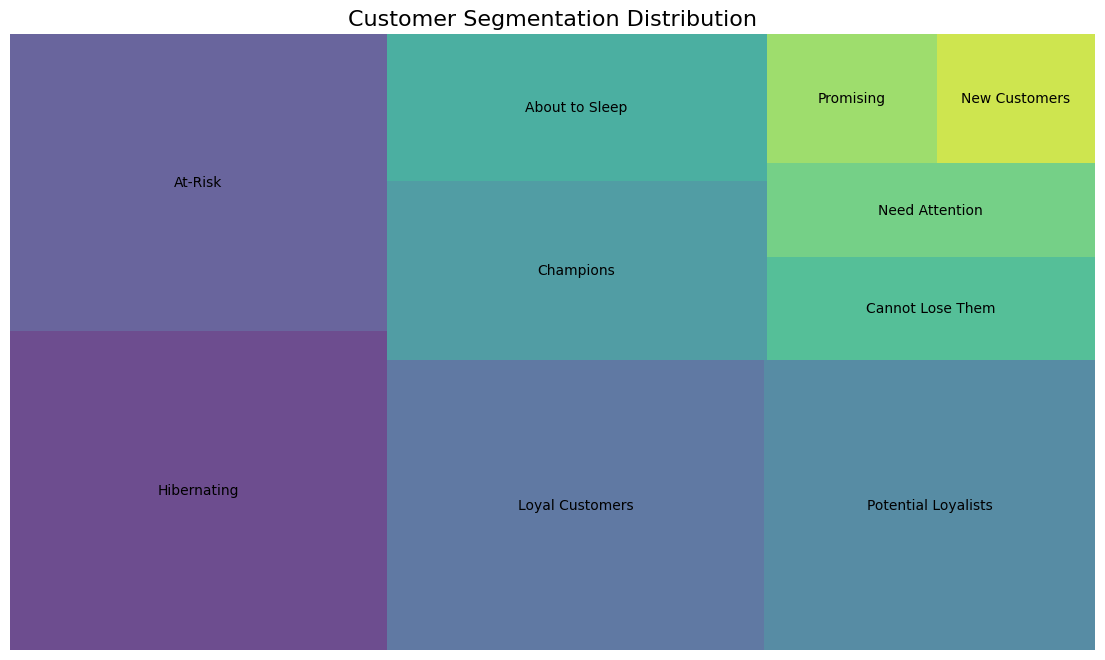

In [10]:
import squarify
import matplotlib.pyplot as plt
import seaborn as sns

# Segment büyüklüklerini hesapla
segments_counts = rfm_scored['Segment'].value_counts().sort_values(ascending=False)

# Treemap ile görselleştir
plt.figure(figsize=(14, 8))
squarify.plot(sizes=segments_counts.values,
              label=segments_counts.index,
              color=sns.color_palette("viridis", len(segments_counts)),
              alpha=0.8)
plt.title('Customer Segmentation Distribution', fontsize=16)
plt.axis('off')
plt.show()

In [12]:
# saving graph
plt.savefig('../reports/figures/customer_segmentation_distribution.png')

<Figure size 640x480 with 0 Axes>

## Saving the RFM Scored DataFrame

In [13]:
rfm_scored.to_csv('../data/rfm_segmented_data.csv', index=True)
print("RFM segmentation scores saved as 'rfm_segmented_data.csv'")

RFM segmentation scores saved as 'rfm_segmented_data.csv'
